In [77]:
import healpy as hp
from scripts.utils import plot_cl_alm, load_data
from scripts.config import SimConfig

import matplotlib.pyplot as plt
from pixell import enmap, lensing, curvedsky, reproject
import numpy as np

In [78]:
def plot(alm, alm2, settings, lmax=1024):
    cl = curvedsky.alm2cl(alm)
    cl2 = curvedsky.alm2cl(alm2)
    ells = settings.ells[2:lmax]
    scale = ells * (ells + 1) / 2 / np.pi

    plt.figure()
    plt.semilogy(ells, scale * cl[2:lmax], label="alm 1 (scaled)")
    plt.semilogy(ells, cl2[2:lmax], label="alm 2")

    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
    # plt.title(title)
    plt.legend()
    plt.grid()

    plt.show()
    plt.close()

In [79]:
# base1 = "scraped/alm_nl_0001_v3.fits"
# alm = hp.read_alm(base1, hdu=(1))
# config_file = "settings/scraped.json"
# s = SimConfig(config_file, False)

# ldata = load_data(s.alm_file_complete, ["alm", "almng"], verbose=s.verbose)

# alm = hp.read_alm(base1, hdu=(1))
# alm2 = ldata["almng"][0,0]
# plot(alm, alm2, settings=s)

#### 
---

In [80]:
from scripts.utils import get_radii
from ksw import Cosmology, Data
import camb
from ksw.radial_functional import radial_func
from tqdm.auto import tqdm


In [81]:

base1 = "scraped/alm_l_0001_v3.fits"
alm_heidelberg_l = hp.read_alm(base1, hdu=(1))

base2 = "scraped/alm_nl_0001_v3.fits"
alm_heidelberg_nl = hp.read_alm(base2, hdu=(1))


In [82]:

config_file = "settings/scraped.json"
s = SimConfig(config_file)

camb_params_obj = camb.set_params(**s.cosmo_params, verbose=s.verbose)
cosmo = Cosmology(camb_params_obj, verbose=s.verbose)
cosmo.compute_transfer(s.cosmo_params["max_l"], verbose=s.verbose)
cosmo.compute_c_ell()

noise_ell, beam_ell = s.get_noise_beam()
ksw_data = Data(s.lmax, noise_ell, beam_ell, s.polarizations, cosmo)

c_ells = ksw_data.cosmology.c_ell["unlensed_scalar"]  # type: ignore
tr_ell_k = ksw_data.cosmology.transfer["tr_ell_k"]
tr_ells = ksw_data.cosmology.transfer["ells"]
tr_k = ksw_data.cosmology.transfer["k"]

mask = tr_ells <= s.lmax
tr_ell_k = tr_ell_k[mask]
tr_ells = tr_ells[mask]

radii, drs = get_radii(s.settings["r_min"], s.settings["r_max"])


Loaded settings from file: settings/scraped.json
{ 'alm_cache_dir': 'data/alm_cache',
  'base_dir': 'data',
  'beam_width': 7.1,
  'cosmo_params': { 'AccuracyBoost': 2.0,
                    'As': 2.457e-09,
                    'DoLateRadTruncation': False,
                    'H0': 70.1,
                    'TCMB': 2.7255,
                    'lAccuracyBoost': 2.0,
                    'lSampleBoost': 2.0,
                    'lens_potential_accuracy': 2,
                    'lmax': 1024,
                    'max_l': 1500,
                    'mnu': 0.06,
                    'ns': 0.96,
                    'ombh2': 0.02256,
                    'omch2': 0.1143,
                    'pivot_scalar': 0.05,
                    'r': 0,
                    'tau': 0.084},
  'debug': True,
  'disable_noise': True,
  'double_precision': False,
  'fnl_range': [0, 0],
  'force_alm_gen': True,
  'lensing': False,
  'name': 'scraped',
  'narray': 1,
  'noise_scale_ee': 4.3,
  'noise_scale_te': 0.43,


In [83]:
delta_phi = 2 * np.pi**2 * s.cosmo_params["As"] * (3/5)**2

f_k = np.ones((len(tr_k), 2), dtype=s.r_dtype) * 5/3                        # f_k for alpha
f_k[:, 1] = tr_k**(-2) * delta_phi  # f_k for beta

def interpolate_ells(func, ells_sparse, ls, axis=1):
    from scipy.interpolate import CubicSpline
    """Our interpolation function to go from space to dense ells."""
    return CubicSpline(ells_sparse, func, axis)(ls)

rad = radial_func(f_k, tr_ell_k, tr_k, radii, tr_ells)

alpha_ell = rad[:, :, :, 0]
alpha_l = np.concatenate(np.array([interpolate_ells(alpha_ell, tr_ells, s.ells)]))
alpha_l = np.ascontiguousarray(alpha_l)

beta_ell = rad[:, :, :, 1]
c_ells_new = c_ells["c_ell"][tr_ells, : s.npol]
div = beta_ell / c_ells_new[np.newaxis, :, :]

bl_div_cl = np.concatenate(np.array([interpolate_ells(div, tr_ells, s.ells)]))
bl_div_cl = np.ascontiguousarray(bl_div_cl)

beam_ell_2d = np.atleast_2d(beam_ell)

alm_sim_g = np.array(
    [
        ksw_data.compute_alm_sim(s.lensing)
        for _ in tqdm(range(s.nsims), desc="a_lm progress")
    ],
    dtype=s.c_dtype,
)
alm_sim_g = alm_sim_g[0,0]


a_lm progress:   0%|          | 0/1 [00:00<?, ?it/s]

In [84]:
print(alm_sim_g.shape,
bl_div_cl.shape,
alpha_l.shape,
radii.shape,
drs.shape)

(525825,) (1200, 1025, 2) (1200, 1025, 2) (1200,) (1199,)


In [85]:
def get_alm(alm, bl_div_cl, alpha_l, r, dr):
    """This calculates the alms from the precalculated values"""
    Balm = hp.almxfl(alm, bl_div_cl, inplace=False)
    B = hp.alm2map(Balm, nside=s.nside, lmax=s.lmax, pol=True, inplace=True)
    inner = hp.map2alm(B**2, lmax=s.lmax, pol=True, use_pixel_weights=True)
    kernel = hp.almxfl(inner, alpha_l, inplace=True)
    return dr * r**2 * kernel

from joblib import Parallel, delayed

lmax = hp.Alm.getlmax(len(alm_heidelberg_l))
cl = curvedsky.alm2cl(alm_heidelberg_l)
ells = np.arange(0, lmax+1)
scale = ells * (ells + 1) / 2 / np.pi
alm_heidelberg_l_s = hp.synalm(cl, lmax=lmax)

alm_gen = Parallel(
    n_jobs=-1, verbose=1, return_as="generator"
)(
    delayed(get_alm)(
        alm_heidelberg_l,
        bl_div_cl[ri, :, 0],
        alpha_l[ri, :, 0],
        radii[ri],
        drs[ri],
    )
    for ri in range(len(drs))
)

# consume
alm_hybrid_ng = np.zeros((s.nelem), dtype=s.c_dtype)
for alm in alm_gen:
    alm_hybrid_ng += alm

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   30.7s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:   55.5s
[Parallel(n_jobs=-1)]: Done 1199 out of 1199 | elapsed:  1.4min finished


In [86]:
alm_gen = Parallel(
    n_jobs=-1, verbose=1, return_as="generator"
)(
    delayed(get_alm)(
        alm_sim_g,
        bl_div_cl[ri, :, 0],
        alpha_l[ri, :, 0],
        radii[ri],
        drs[ri],
    )
    for ri in range(len(drs))
)

# consume
alm_sim_ng = np.zeros((s.nelem), dtype=s.c_dtype)
for alm in alm_gen:
    alm_sim_ng += alm

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   30.7s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:   55.4s
[Parallel(n_jobs=-1)]: Done 1199 out of 1199 | elapsed:  1.4min finished


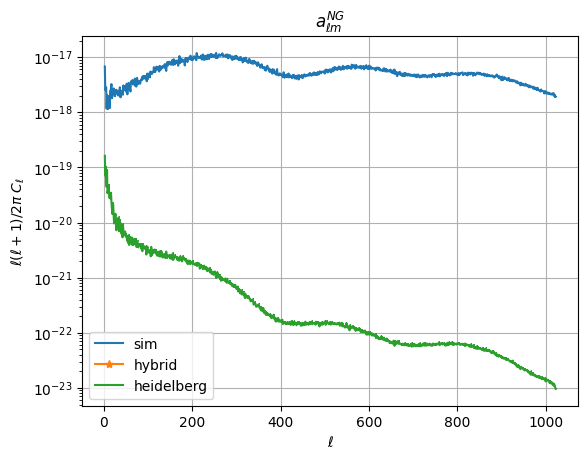

[ 5.4191016e-20+0.0000000e+00j -1.5862551e-22+0.0000000e+00j
  6.5790779e-23+0.0000000e+00j ...  1.6185252e-22+3.1545911e-22j
 -7.1579730e-23+1.4684362e-23j -4.5689293e-23-1.2543821e-23j]


In [87]:
lmax = hp.Alm.getlmax(len(alm_sim_ng))

cl_sim = curvedsky.alm2cl(alm_sim_ng)
cl_hybrid = curvedsky.alm2cl(alm_hybrid_ng)
cl_heidelberg = curvedsky.alm2cl(alm_heidelberg_nl)

ells = s.ells[2:lmax]
scale = ells * (ells + 1) / 2 / np.pi

plt.figure()
plt.semilogy(ells, cl_sim[2:lmax], label="sim")
plt.semilogy(ells, cl_hybrid[2:lmax], marker="*", label="hybrid")
plt.semilogy(ells, cl_heidelberg[2:lmax], marker=',', label="heidelberg")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
plt.title('$a_{\ell m}^{NG}$')
plt.legend()
plt.grid()

plt.show()
plt.close()

print(alm_hybrid_ng)

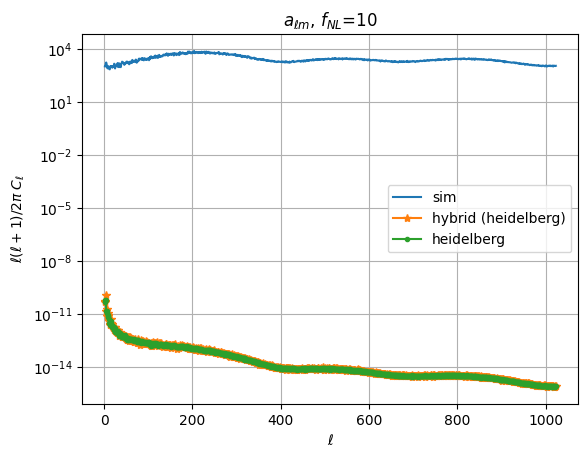

In [89]:
fnl = 10
lmax = hp.Alm.getlmax(len(alm_sim_ng))

cl_sim_ng = curvedsky.alm2cl(alm_sim_ng)
cl_hybrid = curvedsky.alm2cl(alm_hybrid_ng)

alm_sim = alm_sim_g + fnl * alm_sim_ng
alm_hybrid = alm_heidelberg_l_s + fnl * alm_hybrid_ng
alm_heidelberg = alm_heidelberg_l + fnl * alm_heidelberg_nl

cl_sim = curvedsky.alm2cl(alm_sim)
cl_hybrid = curvedsky.alm2cl(alm_hybrid)
cl_heidelberg = curvedsky.alm2cl(alm_heidelberg)
ells = s.ells[2:lmax]
scale = ells * (ells + 1) / 2 / np.pi

plt.figure()
plt.semilogy(ells, cl_sim[2:lmax], label="sim")
plt.semilogy(ells, cl_hybrid[2:lmax], marker="*", label="hybrid (heidelberg)")
plt.semilogy(ells, cl_heidelberg[2:lmax], marker='.', label="heidelberg")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
plt.title('$a_{\ell m}$, $f_{NL}$=' + str(fnl))
plt.legend()
plt.grid()

plt.show()
plt.close()
